In [43]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
df = pd.read_csv("cleaned_child_malnutrition_data.csv")

In [27]:
df.head()

,Country Name,Year,"Literacy rate, adult female (% of females ages 15 and above)",Pregnant women receiving prenatal care (%),"Prevalence of stunting, height for age (% of children under 5)",Region_Type
0,Afghanistan,2004,73.372808,85.757125,59.3,1
1,Afghanistan,2013,73.372808,85.757125,40.4,0
2,Afghanistan,2018,73.372808,65.200000,38.2,0
3,Afghanistan,2022,26.600000,85.757125,44.6,1
4,Albania,2005,73.372808,97.100000,26.7,0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 845 entries, 0 to 844
Data columns (total 6 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   Country Name                                                    845 non-null    object 
 1   Year                                                            845 non-null    int64  
 2   Literacy rate, adult female (% of females ages 15 and above)    845 non-null    float64
 3   Pregnant women receiving prenatal care (%)                      845 non-null    float64
 4   Prevalence of stunting, height for age (% of children under 5)  845 non-null    float64
 5   Region_Type                                                     845 non-null    int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 39.7+ KB


In [33]:
df.shape

(845, 6)

In [35]:
df.describe()

,Year,"Literacy rate, adult female (% of females ages 15 and above)",Pregnant women receiving prenatal care (%),"Prevalence of stunting, height for age (% of children under 5)",Region_Type
count,845.000000,845.000000,845.000000,845.000000,845.000000
mean,2011.552663,73.372808,85.757125,23.869586,0.343195
std,6.729797,14.013167,11.455161,15.038355,0.475057
min,2000.000000,12.800000,26.100000,0.500000,0.000000
25%,2006.000000,73.372808,85.757125,10.700000,0.000000
50%,2012.000000,73.372808,85.757125,23.600000,0.000000
75%,2017.000000,73.372808,91.700000,35.100000,1.000000
max,2023.000000,100.000000,100.000000,64.000000,1.000000


In [37]:
df.isna().sum()

Country Name                                                      0
Year                                                              0
Literacy rate, adult female (% of females ages 15 and above)      0
Pregnant women receiving prenatal care (%)                        0
Prevalence of stunting, height for age (% of children under 5)    0
Region_Type                                                       0
dtype: int64

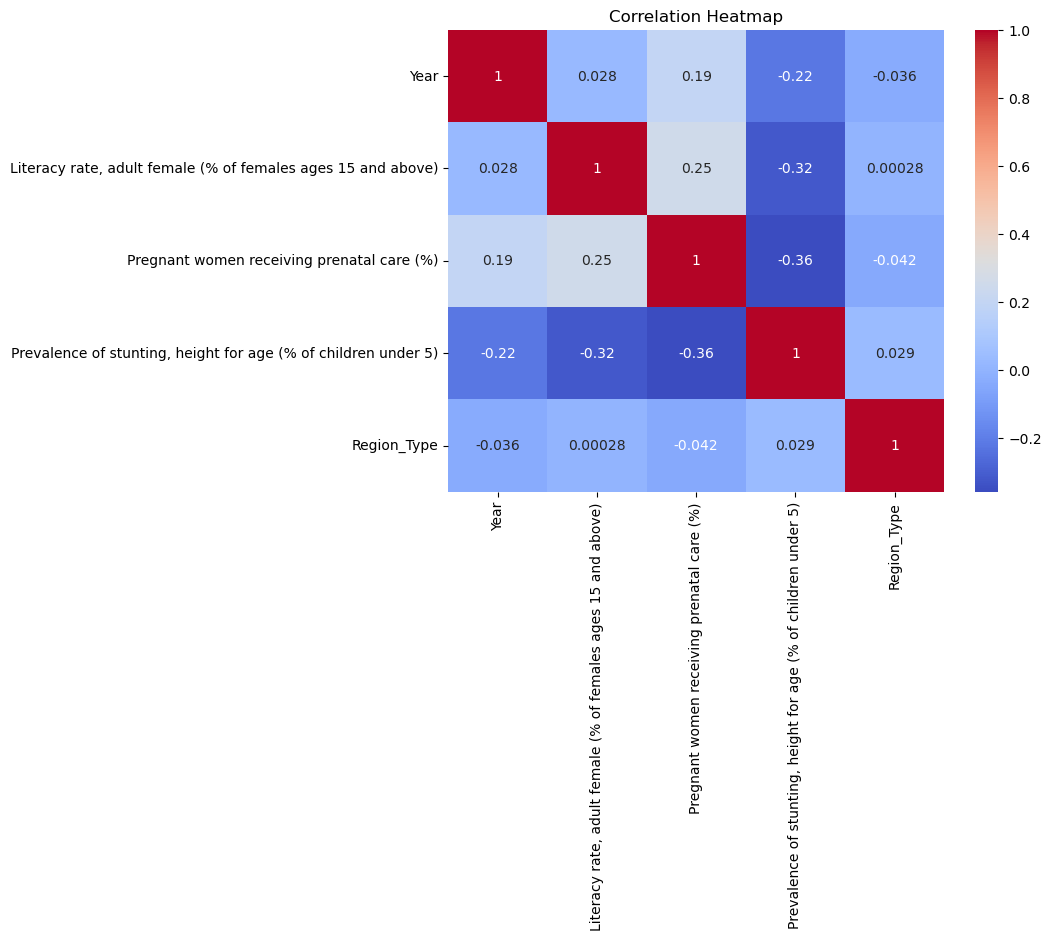

In [59]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

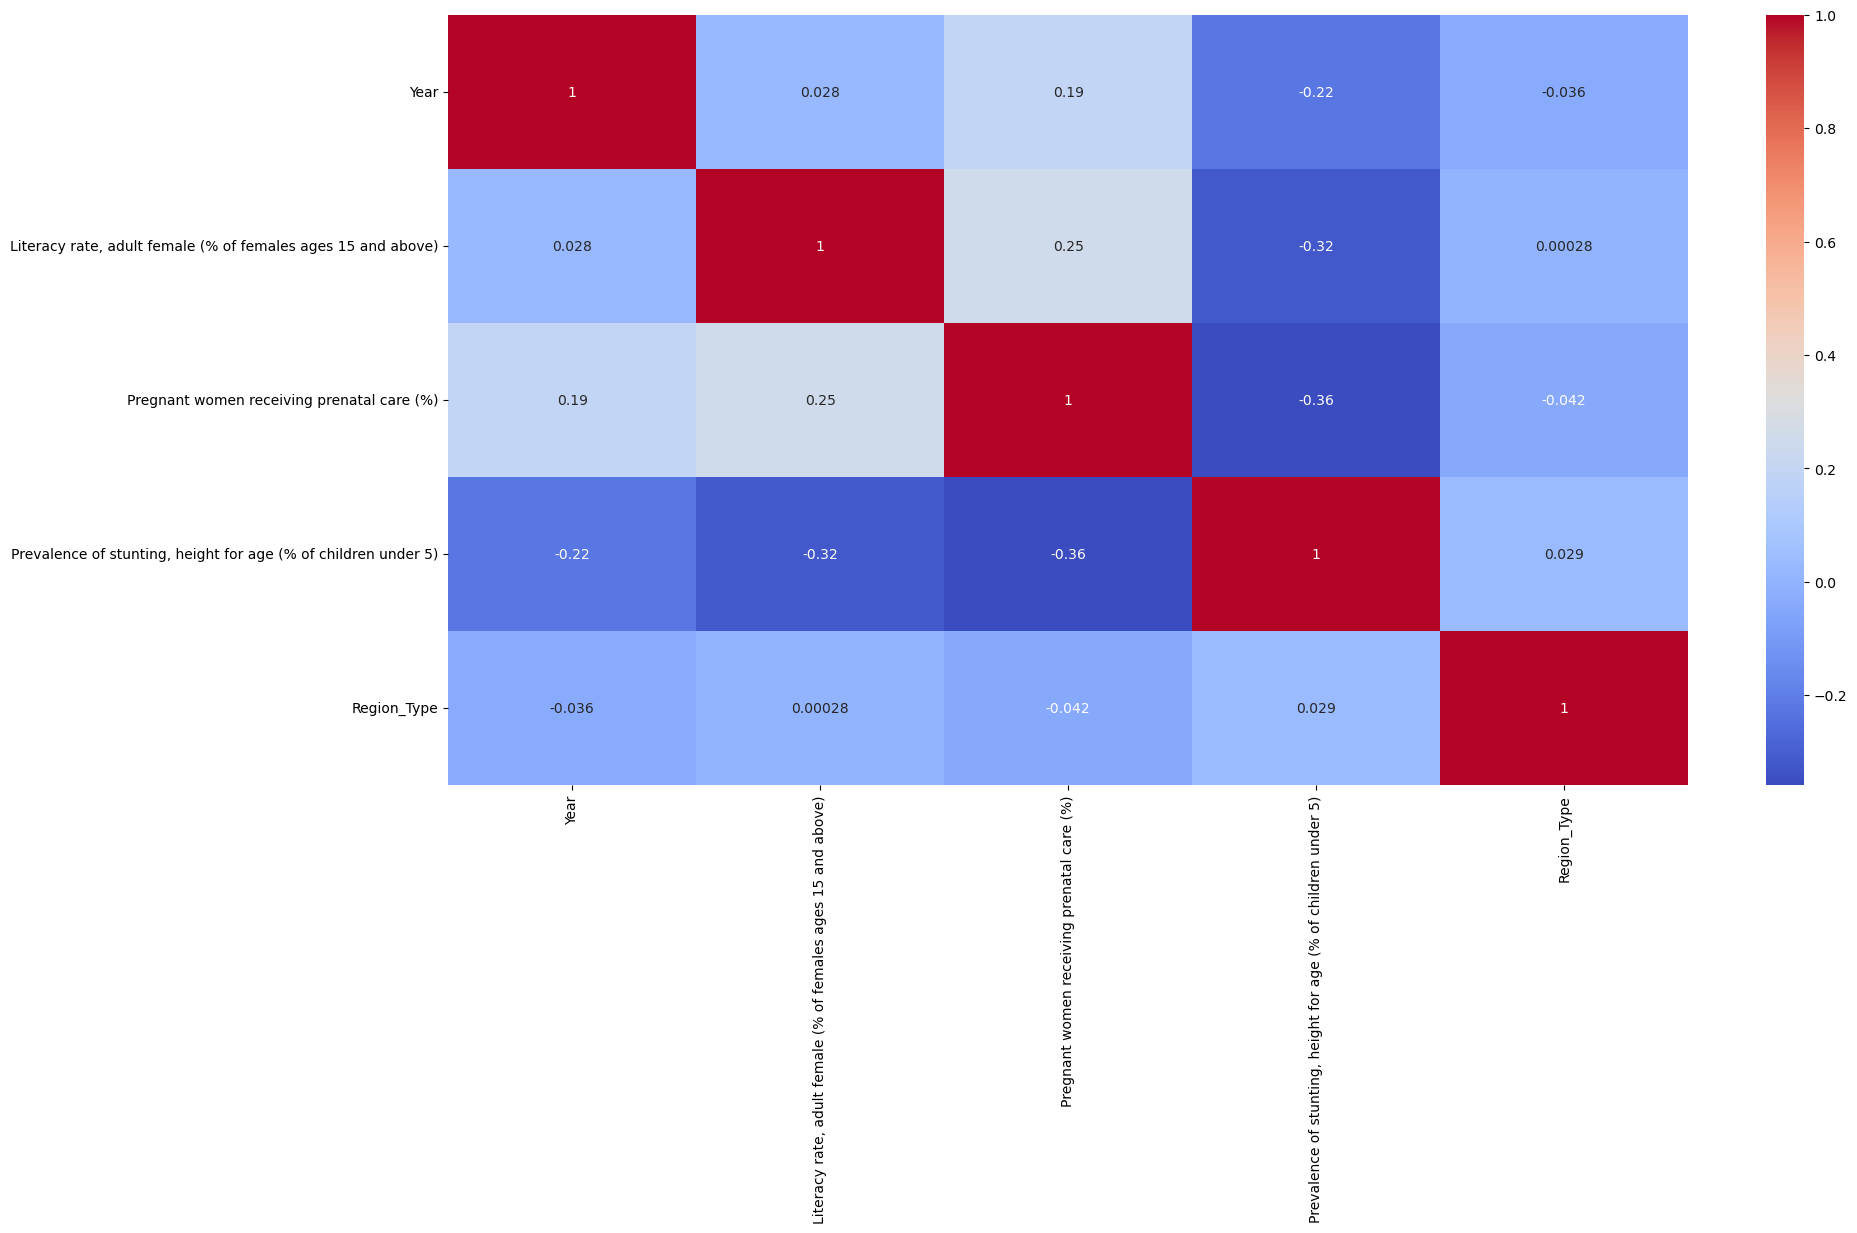

In [73]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

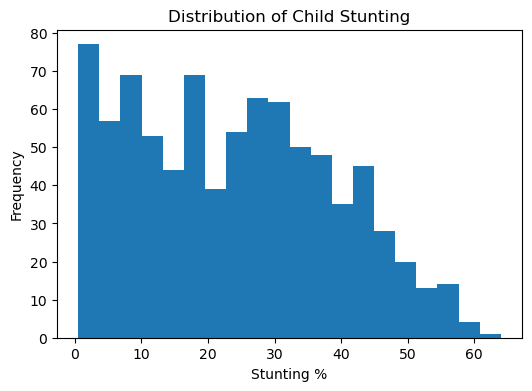

In [75]:
#stunting distribution
plt.figure(figsize=(6,4))
plt.hist(
    df["Prevalence of stunting, height for age (% of children under 5)"],
    bins=20
)

plt.xlabel("Stunting %")
plt.ylabel("Frequency")
plt.title("Distribution of Child Stunting")
plt.show()

C:\Users\safda\AppData\Local\Temp\ipykernel_21104\2805605084.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  literacy_mean = df.groupby("Literacy_Bin")[


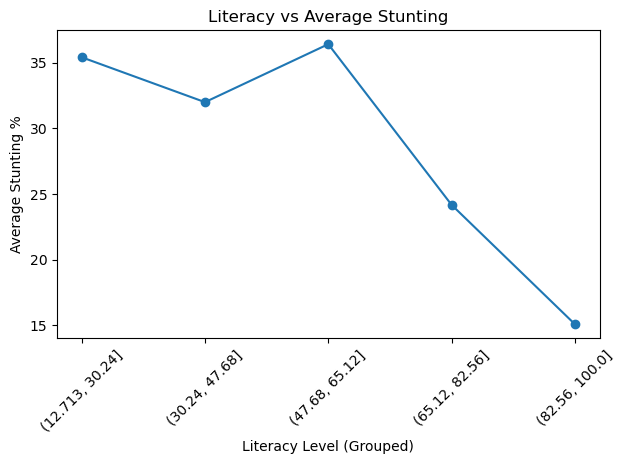

In [77]:
#Literacy vs Stunting
df["Literacy_Bin"] = pd.cut(
    df["Literacy rate, adult female (% of females ages 15 and above)"],
    bins=5
)

literacy_mean = df.groupby("Literacy_Bin")[
    "Prevalence of stunting, height for age (% of children under 5)"
].mean()

plt.figure(figsize=(7,4))
plt.plot(literacy_mean.values, marker='o')

plt.xticks(range(len(literacy_mean.index)), literacy_mean.index, rotation=45)
plt.xlabel("Literacy Level (Grouped)")
plt.ylabel("Average Stunting %")
plt.title("Literacy vs Average Stunting")
plt.show()

C:\Users\safda\AppData\Local\Temp\ipykernel_21104\525777268.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prenatal_mean = df.groupby("Prenatal_Bin")[


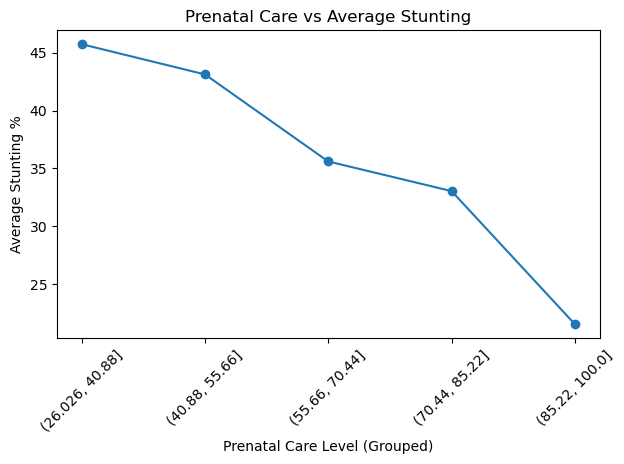

In [79]:
#Prenatal Care vs Stunting
df["Prenatal_Bin"] = pd.cut(
    df["Pregnant women receiving prenatal care (%)"],
    bins=5
)

prenatal_mean = df.groupby("Prenatal_Bin")[
    "Prevalence of stunting, height for age (% of children under 5)"
].mean()

plt.figure(figsize=(7,4))
plt.plot(prenatal_mean.values, marker='o')

plt.xticks(range(len(prenatal_mean.index)), prenatal_mean.index, rotation=45)
plt.xlabel("Prenatal Care Level (Grouped)")
plt.ylabel("Average Stunting %")
plt.title("Prenatal Care vs Average Stunting")
plt.show()

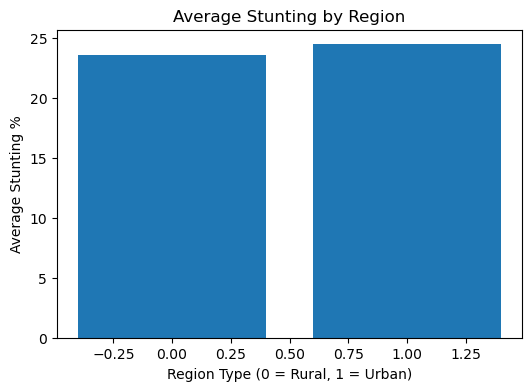

In [83]:
# Region Comparison
region_mean = df.groupby("Region_Type")[
    "Prevalence of stunting, height for age (% of children under 5)"
].mean()

plt.figure(figsize=(6,4))
plt.bar(region_mean.index, region_mean.values)

plt.xlabel("Region Type (0 = Rural, 1 = Urban)")
plt.ylabel("Average Stunting %")
plt.title("Average Stunting by Region")
plt.show()

In [11]:


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [12]:


data = pd.read_csv("cleaned_child_malnutrition_data.csv")

data.head()

,Country Name,Year,"Literacy rate, adult female (% of females ages 15 and above)",Pregnant women receiving prenatal care (%),"Prevalence of stunting, height for age (% of children under 5)",Region_Type
0,Afghanistan,2004,73.372808,85.757125,59.3,1
1,Afghanistan,2013,73.372808,85.757125,40.4,0
2,Afghanistan,2018,73.372808,65.200000,38.2,0
3,Afghanistan,2022,26.600000,85.757125,44.6,1
4,Albania,2005,73.372808,97.100000,26.7,0


In [ ]:
X = data[features]

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load data
data = pd.read_csv("cleaned_child_malnutrition_data.csv")

# Remove non-numeric columns
data = data.select_dtypes(include=['number'])

# Target
y = data["Prevalence of stunting, height for age (% of children under 5)"]

# Features
X = data.drop(columns=["Prevalence of stunting, height for age (% of children under 5)"])

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [17]:
from sklearn.metrics import r2_score

pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))

R2 Score: 0.23387001014750797
